**Charger le dataset nettoyé & poser le problème ML**

In [2]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/DATASETS/dataset_energie_batiments_nettoye_atelier1.csv")

DATASET Energie - Variables pertinentes possibles :

surface_m2

co2_emissions_kg

year_built

On exclut :

energy_consumption_kwh (ancienne cible)

**Étape 1 – Scaling**

In [5]:
from sklearn.preprocessing import StandardScaler

features = ["surface_m2", "co2_emissions_kg", "year_built"]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Sélection des variables :  
**features = les colonnes pour le clustering** :
-surface_m2 → taille du bâtiment
-co2_emissions_kg → émissions de CO₂
-year_built → année de construction

Pourquoi scaler ?  
Ces variables n’ont pas la même échelle :

year_built ≈ entre 1950 et 2022

surface_m2 ≈ entre 20 et 250

co2_emissions_kg ≈ autour de 40–300
Sans standardisation, la variable avec les plus grands nombres (souvent year_built) domine la distance.

StandardScaler :  
Pour chaque variable, il transforme en :

z=(x-moyenne)/ecart type

Résultat : chaque feature a moyenne ≈ 0 et écart-type ≈ 1.

Comment savoir si c’est “bon” ?

Normal : X_scaled contient des valeurs positives et négatives, souvent entre -3 et 3.

Si tu regardes X_scaled[:5], tu dois voir des nombres sans unité, pas des années ni des m².

In [6]:
X_scaled[:5]

array([[ 0.47675918, -1.19298098,  0.40923237],
       [-0.20173363,  2.40412125,  0.50484741],
       [ 0.01196489, -0.21985188, -1.12060827],
       [ 1.57196411,  0.04080771, -0.69034059],
       [-0.30591166,  1.76116094, -0.73814811]])

**Étape 2 – Méthode du coude**

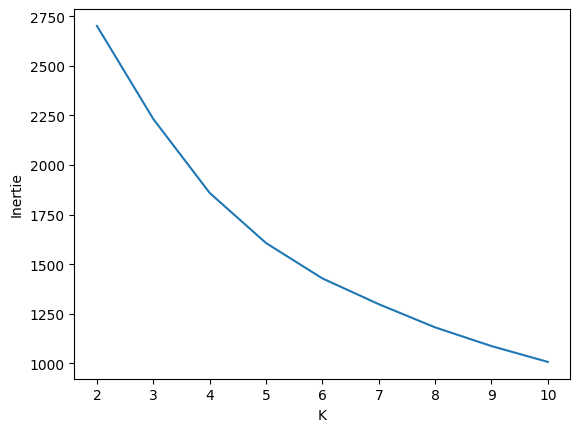

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(range(2,11), inertia)
plt.xlabel("K")
plt.ylabel("Inertie")
plt.show()


Inertie :  
C’est la somme des distances au carré entre chaque point et le centre de son cluster.
Plus l’inertie est faible, plus les points sont proches de leur centre.

Boucle sur k :  
On teste K de 2 à 10 clusters.
Pour chaque K :

On entraîne un KMeans

On stocke model.inertia_ dans la liste inertia.

Graphique :  
On trace inertie en fonction de K → “méthode du coude”.

Scénarios possibles :

Cas “idéal” : coude clair

La courbe baisse beaucoup entre K=2 et K=3, puis beaucoup moins après.

Tu vois un angle marqué vers K=3 ou K=4 → bon candidat pour K.

Cas “pas clair” :

La courbe descend de façon régulière, sans vrai coude → plus difficile.

Dans ce cas, tu complètes avec le score silhouette (Étape 3) et l’interprétation métier.

**Étape 3 – Score silhouette**

In [8]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, silhouette={score}")


K=2, silhouette=0.25378191339149014
K=3, silhouette=0.23349118365344435
K=4, silhouette=0.23724840869982383
K=5, silhouette=0.2238832708822927
K=6, silhouette=0.23666040173310557
K=7, silhouette=0.2304287199329976
K=8, silhouette=0.23393919799129317
K=9, silhouette=0.23783296084140165
K=10, silhouette=0.2428295202805396


Silhouette score :  
Mesure à quel point les points sont :

proches de leur propre cluster

loin des autres clusters

Le score est entre -1 et 1 :

proche de 1 → clusters bien séparés

autour de 0 → clusters qui se chevauchent

négatif → mauvais clustering (points mal assignés)

Boucle :  
Pour chaque K, on :

entraîne KMeans

récupère les labels (labels)

calcule silhouette_score

affiche le score

Scénarios “bons” ou “mauvais” :

Bon signe :

Un K avec un score silhouette nettement plus élevé que les autres (ex : K=3 avec 0.45 alors que les autres sont à 0.2–0.3).

Mauvais signe :

Tous les scores sont bas (ex : < 0.2) → les clusters ne sont pas très distincts.

Score négatif → KMeans ne trouve pas de structure claire.

**Étape 4 – Modèle final**

In [11]:
k_optimal = 6  # exemple
model = KMeans(n_clusters=k_optimal, random_state=42)
df["Cluster"] = model.fit_predict(X_scaled)


Choix de K :  
Tu choisis k_optimal en te basant sur :

le coude (Étape 2)

le score silhouette (Étape 3)

le sens métier (3–5 clusters souvent raisonnables)

Création de la colonne Cluster :  
df["Cluster"] contient un numéro de cluster (0, 1, 2, …) pour chaque bâtiment.

Ce qui est “bon” :

Tu peux expliquer chaque cluster avec des mots simples :

Cluster 0 : “petits bâtiments récents, peu émetteurs”

Cluster 1 : “grands bâtiments anciens, très émetteurs”

etc.

Si tu n’arrives pas à donner un sens aux clusters, soit K n’est pas adapté, soit les variables choisies ne suffisent pas.

**Étape 5 – Profil des clusters**

In [12]:
df.groupby("Cluster")[features].mean()


,surface_m2,co2_emissions_kg,year_built
Cluster,,,
0,103.676720,23.191534,1968.465608
1,121.861885,41.434016,1964.356557
2,125.112639,27.889591,2007.420074
3,176.382353,30.764118,1977.994118
4,71.802353,39.037059,1993.052941
5,134.725316,48.701266,2000.702532


On calcule la moyenne de surface_m2, co2_emissions_kg, year_built pour chaque cluster.

Ça te donne un “portrait moyen” de chaque groupe.

Exemples de profils possibles :

Imaginons que tu obtiennes quelque chose comme :

Cluster	surface_m2	co2_emissions_kg	year_built
0	80	100	2010
1	150	250	1960
2	120	180	1985
Interprétation possible :

Cluster 0 : petits bâtiments récents, faibles émissions → “bâtiments performants”

Cluster 1 : grands bâtiments anciens, fortes émissions → “bâtiments à rénover en priorité”

Cluster 2 : intermédiaires en tout → “profil moyen”

Bon signe :

Les moyennes sont vraiment différentes entre clusters (par ex. 80 m² vs 150 m², 100 kg vs 250 kg).

Tu peux relier ça à une logique métier (priorisation des rénovations, typologie de parc, etc.).

**Étape 6 – Visualisation**

<Axes: xlabel='surface_m2', ylabel='co2_emissions_kg'>

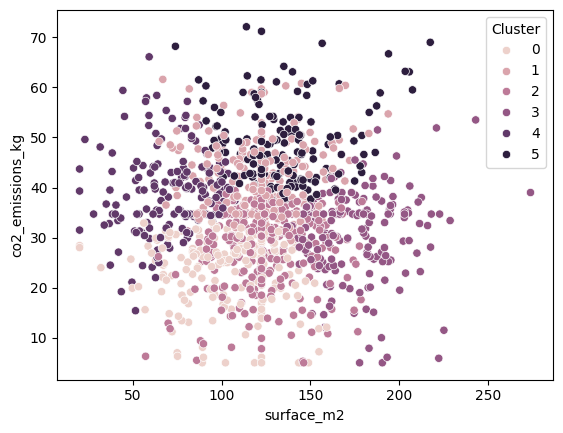

In [13]:
import seaborn as sns

sns.scatterplot(
    x="surface_m2",
    y="co2_emissions_kg",
    hue="Cluster",
    data=df
)


Chaque point = un bâtiment.

Axe X : surface_m2

Axe Y : co2_emissions_kg

Couleur = cluster.

Ce que tu regardes :

Clusters bien séparés :

Les couleurs forment des nuages distincts (par exemple, un groupe de petits bâtiments peu émetteurs, un groupe de grands très émetteurs).

Clusters mélangés :

Les couleurs sont très entremêlées → KMeans a du mal à trouver des groupes nets avec ces variables.

**Comment savoir si “c’est bon” globalement ?**

**Scaling** :

Les valeurs standardisées ne ressemblent plus à des années ou des m² → OK.

**Méthode du coude** :

Tu vois un coude raisonnable (par ex. vers K=3 ou 4) → bon point.

**Silhouette** :

Le K choisi a un score silhouette correct (par ex. > 0.3–0.4) et meilleur que les autres.

**Profils de clusters** :

Les moyennes par cluster sont différentes et interprétables (ex : un cluster clairement plus ancien et plus émetteur).

**Visualisation** :

Les couleurs ne sont pas totalement mélangées, tu vois des zones dominées par un cluster.

Si tu veux, tu peux me dire ce que donnent chez toi :

le graphique du coude,

les scores silhouette,

et un extrait de df.groupby("Cluster")[features].mean(),

et on les interprète ensemble pour voir si tes clusters “racontent une histoire” cohérente.

**Pourquoi ça ne marche pas** ?
Parce que les trois variables choisies ne contiennent pas de structure naturelle.

 dataset  très riche (surface, CO₂, année, type de bâtiment, ville, classe énergie, etc.).
Mais on n’utilise que :

surface_m2

co2_emissions_kg

year_built

Or, dans le fichier, on voit par exemple :

“Industrie – Lyon – 104.1 – 20.9 – F”
“Résidentiel – Marseille – 165.9 – 54.9 – E”

Les bâtiments sont très variés, mais les trois variables numériques seules ne suffisent pas à capturer cette diversité.